# Bacteria movement - excercise 1

In [1]:
# relevant Python libraries

import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# custom functions
import sys
sys.path.append(os.path.abspath('../sandbox'))
import metrics 

import warnings
warnings.filterwarnings("ignore")

metrics.py loaded successfully.


In [2]:
os.getcwd()

'/Users/abdulibrahim/Documents/gitHub/teaching_SoSe26_mobHumAni_exercises/notebooks'

In [3]:
# --------------------------
# loading the data
# --------------------------

base_path = os.path.join("./")
ecoli_path = os.path.join(base_path, "../data", "EcoliTrajectories.mat")

print("Base path:", base_path)
print("E. coli path:", ecoli_path)

ecoli_mat = sio.loadmat(ecoli_path)

print("Keys in E. coli file:", list(ecoli_mat.keys()))

Base path: ./
E. coli path: ./../data/EcoliTrajectories.mat
Keys in E. coli file: ['__header__', '__version__', '__globals__', 'V_10min', 'V_3min', 'V_50min', 'V_7min', 'V_MeAsp1_0511', 'V_MeAsp1_0511_bulk', 'V_MeAsp2_0511', 'V_MeAsp2_0511_bulk', 'V_MeAsp3_0511', 'V_MeAsp3_0511_bulk', 'V_MeAspInverted_1mM_0512_bulk', 'V_MeAsp_0511', 'V_MeAsp_0511_bulk', 'V_MeAsp_0722', 'V_MeAsp_0722_bulk', 'V_MeAsp_0821', 'V_MeAsp_0821_bulk', 'V_MeAsp_1mM_0512_bulk', 'V_Reference_0503_bulk']


# looking into the data

In [4]:
all_keys = list(ecoli_mat.keys())
dataset_keys = [k for k in all_keys if k.startswith('V_')]

In [5]:
dataset_keys

['V_10min',
 'V_3min',
 'V_50min',
 'V_7min',
 'V_MeAsp1_0511',
 'V_MeAsp1_0511_bulk',
 'V_MeAsp2_0511',
 'V_MeAsp2_0511_bulk',
 'V_MeAsp3_0511',
 'V_MeAsp3_0511_bulk',
 'V_MeAspInverted_1mM_0512_bulk',
 'V_MeAsp_0511',
 'V_MeAsp_0511_bulk',
 'V_MeAsp_0722',
 'V_MeAsp_0722_bulk',
 'V_MeAsp_0821',
 'V_MeAsp_0821_bulk',
 'V_MeAsp_1mM_0512_bulk',
 'V_Reference_0503_bulk']

- V_3min    Recording at  3 min delay after loading cells
- V_7min    Recording at  7 min delay
- V_10min   Recording at 10 min delay 
- V_50min   Recording at 50 min delay 

The key insight is:

This is a time series experiment — the same population of cells recorded at 3, 7, 10, 50 minutes
The purpose is to track whether swimming speed changes over time — for example as cells consume oxygen or nutrients




In [6]:
# --------------
# parameters
# -------------

angle_threshold = 45 # angle change threshold for run/tumble classification (degrees)
V_10min = ecoli_mat['V_10min'] # our dataset for now
ref_t = np.logspace(-1.5, 1.5, 100)
# The crossover between the two happens at τ_c (correlation time).
tau_c = 1.6  # τ_c ≈ 1.6 s for wild-type E. coli (from lecture).
Kd, H = 3.1, 10.3   # Hill parameters (Cluzel et al. 2000)

# V   = ecoli_mat['V_10min']

In [7]:
# V_10min # shape is (N, T, 2) where N is number of trajectories, T is number of time points, and 2 corresponds to x and y coordinates.

In [8]:
fps = float(V_10min['Parameters'][0, 0]['fps'][0, 0][0, 0])
dt  = 1.0 / fps
n_traj = len(V_10min['Speeds'][0, 0])
n_traj

150

In [9]:
# V_10min['Speeds'][0, 0][0]

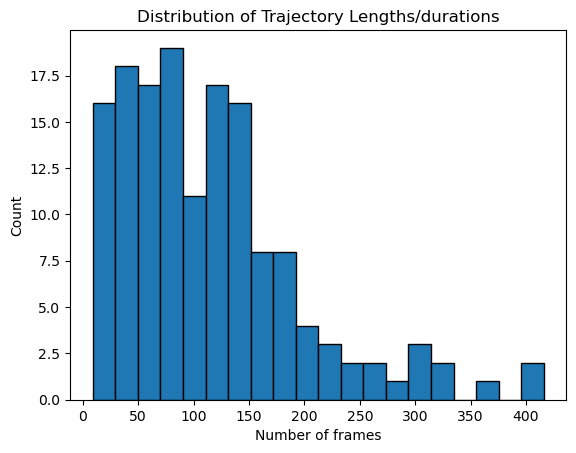

In [10]:
lengths = [len(V_10min['Speeds'][0,0][i][0]) for i in range(n_traj)]
# plot lengths vs time points

plt.hist(lengths, bins=20, edgecolor='black')
plt.title("Distribution of Trajectory Lengths/durations")
plt.xlabel("Number of frames")
plt.ylabel("Count")
plt.show()

In [11]:
raw = V_10min['Speeds'][0, 0][0][0]

for col in range(raw.shape[1]):
    n_nan = np.sum(np.isnan(raw[:, col]))
    print(f"    col {col}: {n_nan} NaN frames")
 

    col 0: 0 NaN frames
    col 1: 0 NaN frames
    col 2: 0 NaN frames
    col 3: 0 NaN frames
    col 4: 0 NaN frames
    col 5: 2 NaN frames
    col 6: 2 NaN frames
    col 7: 2 NaN frames
    col 8: 2 NaN frames
    col 9: 6 NaN frames


In [12]:
# clean: keep only rows where ALL key columns are finite
key_cols  = [1, 2, 3, 5, 6, 7, 8, 9]   # x, y, z, speed, angle
valid     = np.all(np.isfinite(raw[:, key_cols]), axis=1)
n_dropped = (~valid).sum()
raw_clean = raw[valid]

In [13]:
raw.shape[0], raw_clean.shape[0]

(146, 140)

- col 0: frame
- col 1: x_um
- col 2: y_um
- col 3: z_um
- col 4: (empty/unused)
- col 5: vx_um_s   ← col 6 in task
- col 6: vy_um_s   ← col 7 in task
- col 7: vz_um_s   ← col 8 in task
- col 8: speed_um_s ← col 9 in task
- col 9: angle_change_deg ← col 10 in task

In [14]:
df = pd.DataFrame({
    'frame'           : raw_clean[:, 0].astype(int),
    'time_s'          : raw_clean[:, 0] / fps,
    'x_um'            : raw_clean[:, 1],
    'y_um'            : raw_clean[:, 2],
    'z_um'            : raw_clean[:, 3],
    'vx_um_s'         : raw_clean[:, 5],  
    'vy_um_s'         : raw_clean[:, 6],  
    'vz_um_s'         : raw_clean[:, 7],  
    'speed_um_s'      : raw_clean[:, 8],  
    'angle_change_deg': raw_clean[:, 9],  
}).reset_index(drop=True)


In [15]:
df

,frame,time_s,x_um,y_um,z_um,vx_um_s,vy_um_s,vz_um_s,speed_um_s,angle_change_deg
0,4,0.266667,89.100077,258.592708,-41.413207,9.206089,0.019106,-2.158903,9.455861,6.117073
1,5,0.333333,89.839966,258.593537,-41.558005,11.099129,0.005957,-2.158359,11.307043,12.674389
2,6,0.400000,90.579960,258.593502,-41.700988,11.100586,1.163334,-2.156907,11.367876,22.743116
3,7,0.466667,91.320044,258.748648,-41.845593,11.102052,3.763083,-2.159476,11.919719,27.963840
4,8,0.533333,92.060234,259.095246,-41.988918,9.782858,5.205981,-2.155944,11.289582,15.602570
...,...,...,...,...,...,...,...,...,...,...
135,139,9.266667,106.715440,227.903788,-92.459289,-4.326284,0.833863,-1.437248,4.634408,94.750498
136,140,9.333333,106.427141,227.532254,-92.611855,-4.324770,-5.581244,-6.705263,9.737273,92.071739
137,141,9.400000,106.138804,227.159622,-93.353324,-4.323579,-7.591686,-11.123020,14.143854,30.083122
138,142,9.466667,105.850664,226.520029,-94.094924,-4.322467,-9.898077,-7.232434,12.998606,39.883050


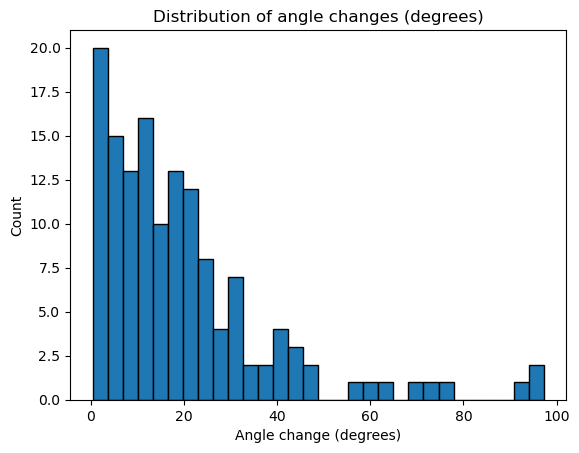

In [16]:
plt.hist(df.angle_change_deg, bins=30, edgecolor='black' )
plt.title("Distribution of angle changes (degrees)")
plt.xlabel("Angle change (degrees)")
plt.ylabel("Count")
plt.show()

In [17]:
mean_speed = df['speed_um_s'].mean()
mean_angle = df['angle_change_deg'].mean()
duration   = df['time_s'].max()

mean_speed, mean_angle, duration

(np.float64(16.28283204200667),
 np.float64(20.035212297609313),
 np.float64(9.533333333333333))

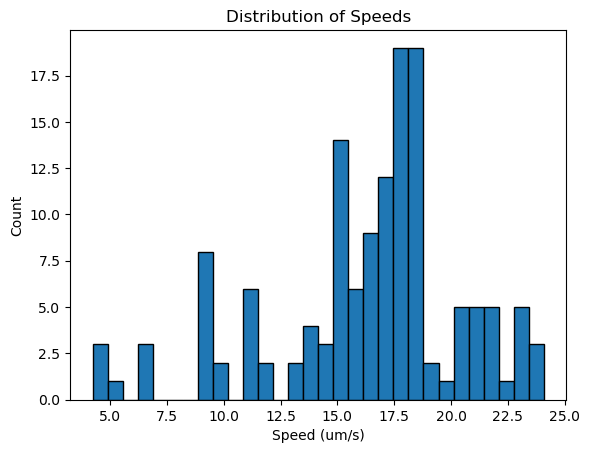

In [18]:
plt.hist(df['speed_um_s'], bins=30, edgecolor='black')
plt.xlabel("Speed (um/s)")
plt.ylabel("Count")
plt.title("Distribution of Speeds")
plt.show()

In [19]:
N_CELLS = 1
COLORS  = ['#1D9E75', '#4A90D9', '#E8825A', '#9B8FD4', '#F0C060'] 
trajs = [metrics.extract_clean(V_10min, i)[0] for i in range(N_CELLS)]


In [20]:
# trajs[0]

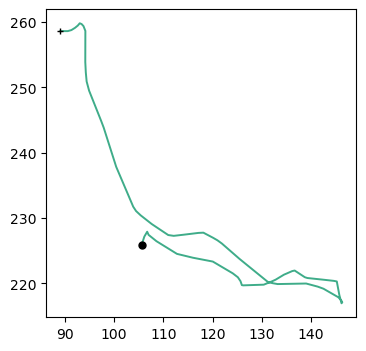

In [21]:
plt.figure(figsize=(4, 4))
plt.plot(df['x_um'], df['y_um'], color=COLORS[0], lw=1.4, alpha=0.85, label=f'cell 1')
plt.plot(df['x_um'].values[0], df['y_um'].values[0], '+', color='black', ms=5, zorder=5)
plt.plot(df['x_um'].values[-1], df['y_um'].values[-1], 'o', color='black', ms=5, zorder=5)
plt.show()

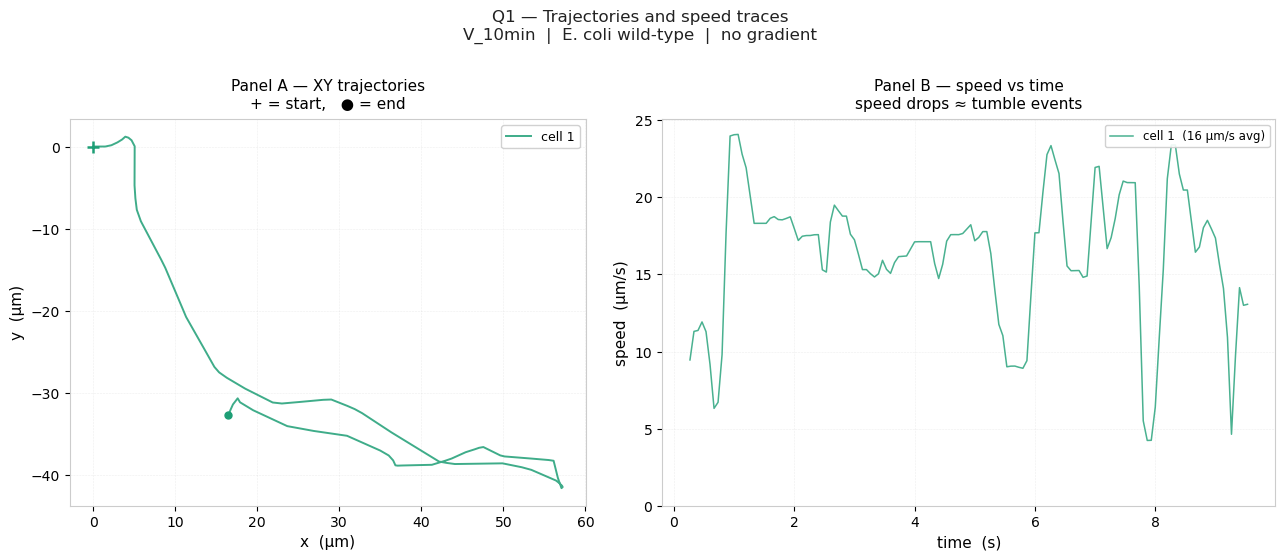

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='white',gridspec_kw={'width_ratios': [1.2, 1.4]})
fig.subplots_adjust(wspace=0.3)
 
# ── Panel A: x-y trajectories ────────────────────────────────
for i, df in enumerate(trajs):
    x = df['x_um'].values - df['x_um'].iloc[0]
    y = df['y_um'].values - df['y_um'].iloc[0]
    ax1.plot(x, y, color=COLORS[i], lw=1.4, alpha=0.85, label=f'cell {i+1}')
    ax1.plot(0, 0, '+', color=COLORS[i], ms=9, mew=1.8, zorder=5)
    ax1.plot(x[-1], y[-1], 'o', color=COLORS[i], ms=5, zorder=5)
 
ax1.set_xlabel('x  (µm)', fontsize=11)
ax1.set_ylabel('y  (µm)', fontsize=11)
ax1.set_title('Panel A — XY trajectories\n' '+ = start,   ● = end', fontsize=11, pad=8)
ax1.set_aspect('equal')
ax1.grid(True, ls='--', lw=0.4, alpha=0.35, color='#ccc')
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')
for sp in ax1.spines.values(): sp.set_edgecolor('#ccc')
 
# ── Panel B: speed vs time ────────────────────────────────────
for i, df in enumerate(trajs):
    ax2.plot(df['time_s'], df['speed_um_s'], color=COLORS[i], lw=1.1, alpha=0.8,
             label=f'cell {i+1}  ' f'({df["speed_um_s"].mean():.0f} µm/s avg)')

# mean speed reference
# all_speeds = np.concatenate([df['speed_um_s'].values for df in trajs])
# mean_v = np.mean(all_speeds)
# ax2.axhline(mean_v, color='#333', lw=1.2, ls='--', alpha=0.5)
# ax2.text(0.01, mean_v + 0.8, f'mean = {mean_v:.1f} µm/s', transform=ax2.get_yaxis_transform(), fontsize=9, color='#333')
 
ax2.set_xlabel('time  (s)', fontsize=11)
ax2.set_ylabel('speed  (µm/s)', fontsize=11)
ax2.set_title('Panel B — speed vs time\n'
              'speed drops ≈ tumble events', fontsize=11, pad=8)
ax2.set_ylim(bottom=0)
ax2.grid(True, ls='--', lw=0.4, alpha=0.35, color='#ccc')
ax2.legend(fontsize=8.5, framealpha=0.9, edgecolor='#ccc',loc='upper right')
for sp in ax2.spines.values(): sp.set_edgecolor('#ccc')
 
fig.suptitle('Q1 — Trajectories and speed traces\n' 'V_10min  |  E. coli wild-type  |  no gradient',
    fontsize=12, y=1.01, color='#222'
)
 
plt.tight_layout()
plt.show()
 

In [48]:
5 ** (1/2)

2.23606797749979

In [23]:
print(f"{'Cell':<6} {'Frames':>7} {'Duration (s)':>14} "
      f"{'Mean speed':>12} {'Speed drops':>12}")
print("-" * 58)
for i, df in enumerate(trajs):
    # count speed drops below 10 µm/s as proxy for tumbles
    drops = (df['speed_um_s'] < 10).sum()
    print(f"{i+1:<6} {len(df):>7} {df['time_s'].max():>14.2f} "
          f"{df['speed_um_s'].mean():>11.1f} "
          f"{drops:>12}")

Cell    Frames   Duration (s)   Mean speed  Speed drops
----------------------------------------------------------
1          140           9.53        16.3           17


## Q2

In [24]:
n_avail = len(V_10min['Speeds'][0, 0])

tumble_freqs = []
cw_biases    = []
n_tumble_all = []
durations    = []

In [25]:
for i in range(n_avail):
    df, fps = metrics.extract_clean(V_10min, i)
    if len(df) < 10:
        continue
 
    total_frames = len(df)
    total_time   = df['time_s'].max()
 
    # classify each frame
    is_tumble    = df['angle_change_deg'] > angle_threshold
    n_tumble     = is_tumble.sum()
 
    f_tumble     = n_tumble / total_time # tumble frequency: tumbles per second
    cw_bias      = n_tumble / total_frames # CW bias proxy: fraction of frames that are tumbling
 
    tumble_freqs.append(f_tumble)
    cw_biases.append(cw_bias)
    n_tumble_all.append(n_tumble)
    durations.append(total_time)
 
tumble_freqs = np.array(tumble_freqs)
cw_biases    = np.array(cw_biases)

df_ex['x_um'].values: 89.10007650523721--df_ex['x_um'].iloc[0]: 89.10007650523721--


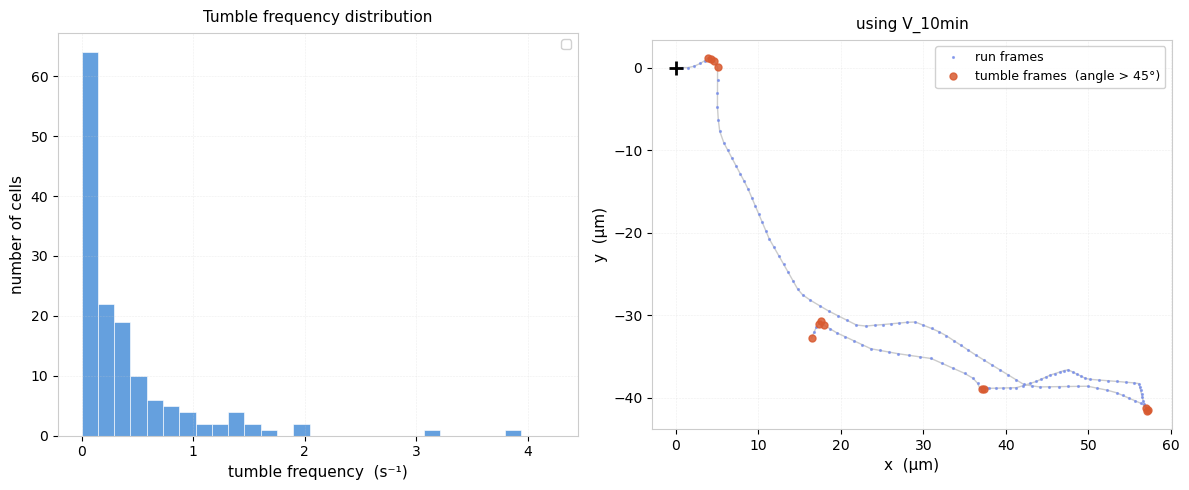

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')
fig.subplots_adjust(wspace=0.32)

# ── Panel A: tumble frequency histogram ──────────────────────
ax1.set_facecolor('white')
bins = np.linspace(0, tumble_freqs.max() * 1.1, 30)
ax1.hist(tumble_freqs, bins=bins,color='#4A90D9', edgecolor='white',linewidth=0.5, alpha=0.85)
ax1.set_xlabel('tumble frequency  (s⁻¹)', fontsize=11)
ax1.set_ylabel('number of cells', fontsize=11)
ax1.set_title('Tumble frequency distribution', fontsize=11, pad=8)
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')
ax1.grid(True, ls='--', lw=0.4, alpha=0.35, color='#ccc')
for sp in ax1.spines.values(): sp.set_edgecolor('#ccc')


# ── Panel B: example trajectory with tumbles marked ──────────
ax2.set_facecolor('white')

# show one representative trajectory with tumble frames highlighted
df_ex, fps_ex = metrics.extract_clean(V_10min, 0)   # cell 4 — usually has nice track
is_tumble_ex  = df_ex['angle_change_deg'] > angle_threshold
print(f"df_ex[\'x_um\'].values: {df_ex['x_um'].values[0]}--df_ex['x_um'].iloc[0]: {df_ex['x_um'].iloc[0]}--")
x = df_ex['x_um'].values - df_ex['x_um'].iloc[0]
y = df_ex['y_um'].values - df_ex['y_um'].iloc[0]

# plot run segments in teal
ax2.plot(x, y, color='#ccc', lw=1.0, zorder=1)   # full path grey
ax2.plot(x[~is_tumble_ex], y[~is_tumble_ex], '.', color="#758CE9", ms=2.5, alpha=0.7, zorder=2, label='run frames')
ax2.plot(x[is_tumble_ex], y[is_tumble_ex],'o', color='#D85A30', ms=5, alpha=0.85, zorder=3, label=f'tumble frames  (angle > {angle_threshold}°)')

ax2.plot(0, 0, '+k', ms=10, mew=2, zorder=5)
ax2.set_aspect('equal')
ax2.set_xlabel('x  (µm)', fontsize=11)
ax2.set_ylabel('y  (µm)', fontsize=11)
ax2.set_title('using V_10min', fontsize=11, pad=8)
ax2.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')
ax2.grid(True, ls='--', lw=0.4, alpha=0.35, color='#ccc')
for sp in ax2.spines.values(): sp.set_edgecolor('#ccc')
'''
fig.suptitle(
    f'using  V_10min  |  threshold = {angle_threshold}°  ',
    fontsize=11, y=1.01, color='#222'
)
'''
plt.tight_layout()
plt.savefig('tumble_trajectory_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

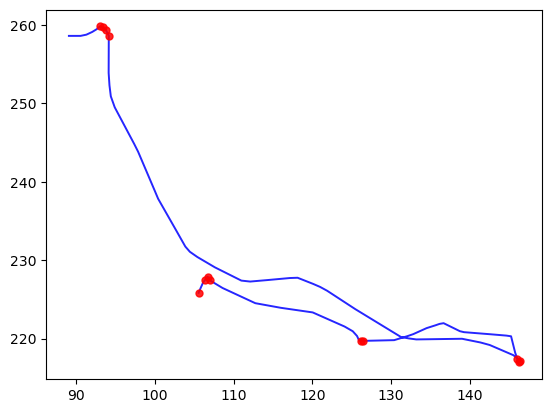

In [27]:
df_ex, fps_ex = metrics.extract_clean(V_10min, 0)
df_ex['tumbler'] = df_ex['angle_change_deg'] > angle_threshold
plt.plot(df_ex['x_um'], df_ex['y_um'], color='blue', lw=1.4, alpha=0.85, label=f'cell 1')
plt.plot(df_ex['x_um'].values[df_ex['tumbler']], df_ex['y_um'].values[df_ex['tumbler']], 'o', color='red', ms=5, alpha=0.85, zorder=3, label=f'tumble frames  (angle > {angle_threshold}°)')
plt.show()

## Q3

In [28]:
from scipy import stats

run_durations = []
 
for i in range(len(V_10min['Speeds'][0, 0])):
    df, fps = metrics.extract_clean(V_10min, i)
    if len(df) < 10:
        continue
 
    dt = 1.0 / fps
    # classify frames
    df['is_tumble'] = df['angle_change_deg'] > angle_threshold
 
    # group into consecutive segments
    df['segment_id'] = (df['is_tumble'] != df['is_tumble'].shift(1)).cumsum()
 
    for seg_id, grp in df.groupby('segment_id'):
        if grp['is_tumble'].iloc[0]:
            continue                    # skip tumble segments
        duration = len(grp) * dt
        if duration > 0.05:             # remove sub-frame noise
            run_durations.append(duration)
 
run_durations = np.array(run_durations)

In [29]:
print("=" * 55)
print("Q3 — Run duration extraction")
print("=" * 55)
print(f"\n  Total run segments found : {len(run_durations)}")
print(f"  Min duration             : {run_durations.min():.3f} s")
print(f"  Max duration             : {run_durations.max():.3f} s")


Q3 — Run duration extraction

  Total run segments found : 688
  Min duration             : 0.067 s
  Max duration             : 18.667 s


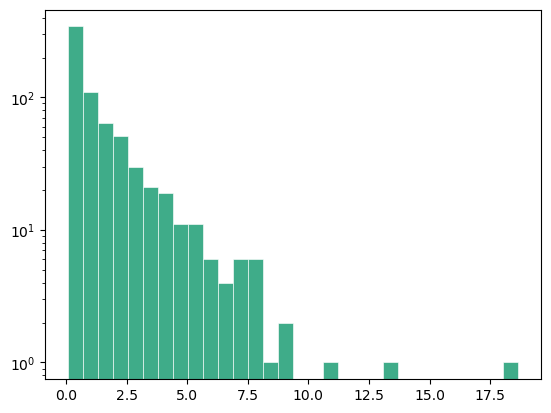

In [30]:
plt.hist(run_durations, bins=30, color='#1D9E75', edgecolor='white', linewidth=0.5, alpha=0.85)
plt.yscale('log') # log scale for better visibility of short runs

In [31]:
len(V_10min['Speeds'][0, 0][:10])

10

## Q4

V_10min — mean CW bias: 0.099  → [CheY-P] ≈ 2.00 µM
V_50min — mean CW bias: 0.121  → [CheY-P] ≈ 2.18 µM


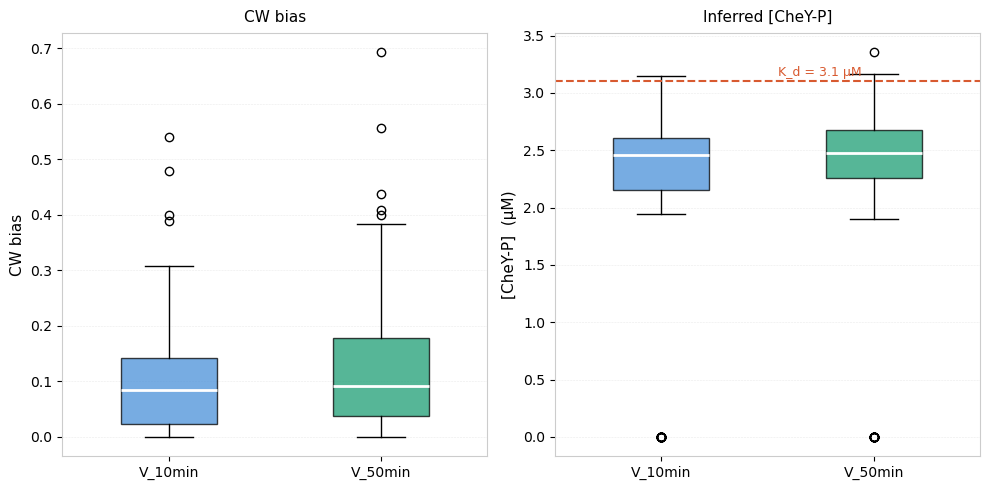

In [32]:
# ============================================================
# Sub-topic 1 — Q4: CW bias across time conditions
# ============================================================



bias_10 = metrics.get_cw_bias(V_10min, angle_threshold) # V_10min = ecoli_mat['V_10min']
bias_50 = metrics.get_cw_bias(ecoli_mat['V_50min'], angle_threshold)

cheyp_10 =  metrics.get_cheyp(Kd, H, bias_10)
cheyp_50 = metrics.get_cheyp(Kd, H, bias_50)

print(f"V_10min — mean CW bias: {bias_10.mean():.3f}  " f"→ [CheY-P] ≈ {cheyp_10.mean():.2f} µM")
print(f"V_50min — mean CW bias: {bias_50.mean():.3f}  " f"→ [CheY-P] ≈ {cheyp_50.mean():.2f} µM")

# ── plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), facecolor='white')

for ax, data, title, ylabel in [
    (ax1, [bias_10, bias_50],   'CW bias',         'CW bias'),
    (ax2, [cheyp_10, cheyp_50], 'Inferred [CheY-P]', '[CheY-P]  (µM)'),
]:
    ax.set_facecolor('white')
    bp = ax.boxplot(data, labels=['V_10min', 'V_50min'],
                    patch_artist=True, widths=0.45,
                    medianprops=dict(color='white', lw=2))
    for patch, color in zip(bp['boxes'], ['#4A90D9', '#1D9E75']):
         patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, axis='y', ls='--', lw=0.4, alpha=0.4, color='#ccc')
    for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

ax2.axhline(Kd, color='#D85A30', lw=1.5, ls='--')
ax2.text(1.55, Kd + 0.05, f'K_d = {Kd} µM', fontsize=9, color='#D85A30')

plt.tight_layout()
plt.savefig('Q4_cw_bias.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

 - CW bias is a dimensionless fraction between 0 and 1. It is simply the proportion of frames where the cell was tumbling. A value of 0.10 means the cell spent 10% of its time tumbling.
 -  [CheY-P] is a concentration in µM, so the y-axis goes from 0 to ~3.5 µM. It is not measured directly — it is inferred by plugging the CW bias into the inverted Hill equation
 - So a CW bias of 0.10 on the left corresponds to roughly 2.4 µM on the right. 

the two near-zero outliers in the right panel correspond to the same outlier cells in the left panel with CW bias ≈ 0. When bias is very close to zero the Hill inversion 
$$c= K_d \cdot \left(\frac{\text{bias}}{1-\text{bias}}\right)^{1/H}$$
 returns values near zero — these cells may be smooth swimmers or have very low CheA activity.



## Q5

In [33]:
angle_threshold

45

Mean speed (all frames) : 20.8 µm/s
Mean speed (runs only)  : 21.5 µm/s  ← true swimming speed
Mean speed (tumbles)    : 12.3 µm/s
CV of run speed         : 0.25  (25%)
D_eff ∝ v² → CV in D_eff ≈ 51%


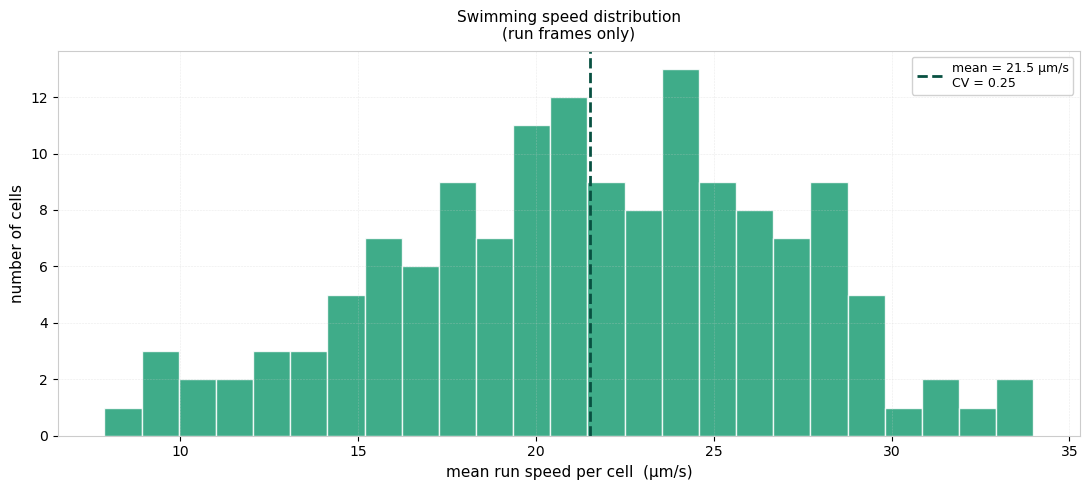

In [34]:
speeds_all    = []
speeds_run    = []
speeds_tumble = []

for i in range(len(V_10min['Speeds'][0, 0])):
    df, fps = metrics.extract_clean(V_10min, i)
    if len(df) < 10: continue

    is_tumble = df['angle_change_deg'] > angle_threshold
    run_speed = df.loc[~is_tumble, 'speed_um_s']
    tum_speed = df.loc[ is_tumble, 'speed_um_s']

    speeds_all.append(df['speed_um_s'].mean())

    if len(run_speed) > 0:
        speeds_run.append(run_speed.mean())
    if len(tum_speed) > 3:           # only include if enough tumble frames
        speeds_tumble.append(tum_speed.mean())

speeds_all    = np.array(speeds_all)
speeds_run    = np.array(speeds_run)
speeds_tumble = np.array(speeds_tumble)

cv = speeds_run.std() / speeds_run.mean()

print(f"Mean speed (all frames) : {speeds_all.mean():.1f} µm/s")
print(f"Mean speed (runs only)  : {speeds_run.mean():.1f} µm/s  ← true swimming speed")
print(f"Mean speed (tumbles)    : {speeds_tumble.mean():.1f} µm/s")
print(f"CV of run speed         : {cv:.2f}  ({cv*100:.0f}%)")
print(f"D_eff ∝ v² → CV in D_eff ≈ {2*cv*100:.0f}%")

# ── plot ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(1, 1, figsize=(11, 5), facecolor='white')

# Panel A — run speed distribution (true swimming speed)
ax1.set_facecolor('white')
ax1.hist(speeds_run, bins=25, color='#1D9E75',edgecolor='white', alpha=0.85)
ax1.axvline(speeds_run.mean(), color='#085041',lw=2, ls='--',
            label=f'mean = {speeds_run.mean():.1f} µm/s\nCV = {cv:.2f}')
ax1.set_xlabel('mean run speed per cell  (µm/s)', fontsize=11)
ax1.set_ylabel('number of cells', fontsize=11)
ax1.set_title('Swimming speed distribution\n(run frames only)', fontsize=11, pad=8)
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')
ax1.grid(True, ls='--', lw=0.4, alpha=0.4, color='#ccc')
for sp in ax1.spines.values(): sp.set_edgecolor('#ccc')

plt.tight_layout()
plt.show()

# t2

df_ex.tumbler.value_counts(): tumbler
False    44
True      4
Name: count, dtype: int64


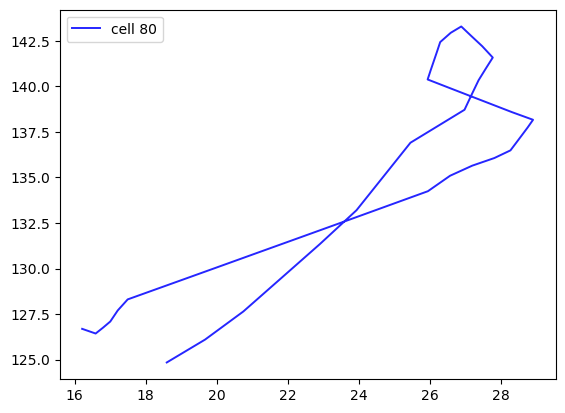

In [35]:
cell_idx = 80
df_ex, fps_ex = metrics.extract_clean(V_10min, cell_idx)
df_ex['tumbler'] = df_ex['angle_change_deg'] > 90 # angle_threshold
print(f'df_ex.tumbler.value_counts(): {df_ex.tumbler.value_counts()}')
x = df_ex['x_um'].values # - df_ex['x_um'].iloc[0]
y = df_ex['y_um'].values # - df_ex['y_um'].iloc[0]
plt.plot(x, y, color='blue', lw=1.4, alpha=0.85, label=f'cell {cell_idx}')
# plt.plot(df_ex.loc[df_ex['tumbler'], 'x_um'], df_ex.loc[df_ex['tumbler'], 'y_um'],'o', color='red', ms=5, alpha=0.85, zorder=3, label=f'tumble frames (angle > {angle_threshold}°)')
plt.legend()
plt.show()

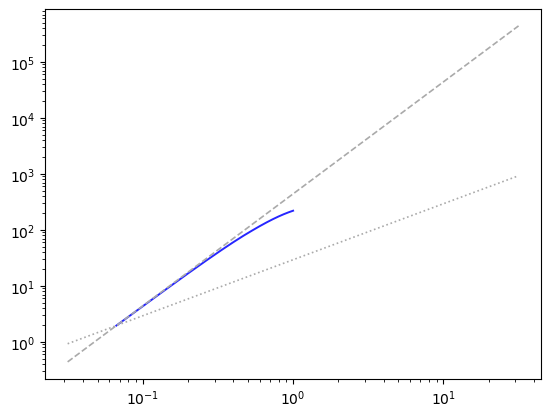

In [36]:
lags, msd = metrics.compute_msd(df_ex)
anchor, t0 = msd[0], lags[0]
plt.loglog(lags, msd, color='blue', lw=1.4, alpha=0.85, label=f'cell 1')
plt.loglog(ref_t, anchor*(ref_t/t0)**2, '--', color='#aaa', lw=1.2, label='∝ τ²  (ballistic)')
plt.loglog(ref_t, anchor*(ref_t/t0)**1, ':', color='#aaa', lw=1.2, label='∝ τ  (diffusive)')
plt.show()

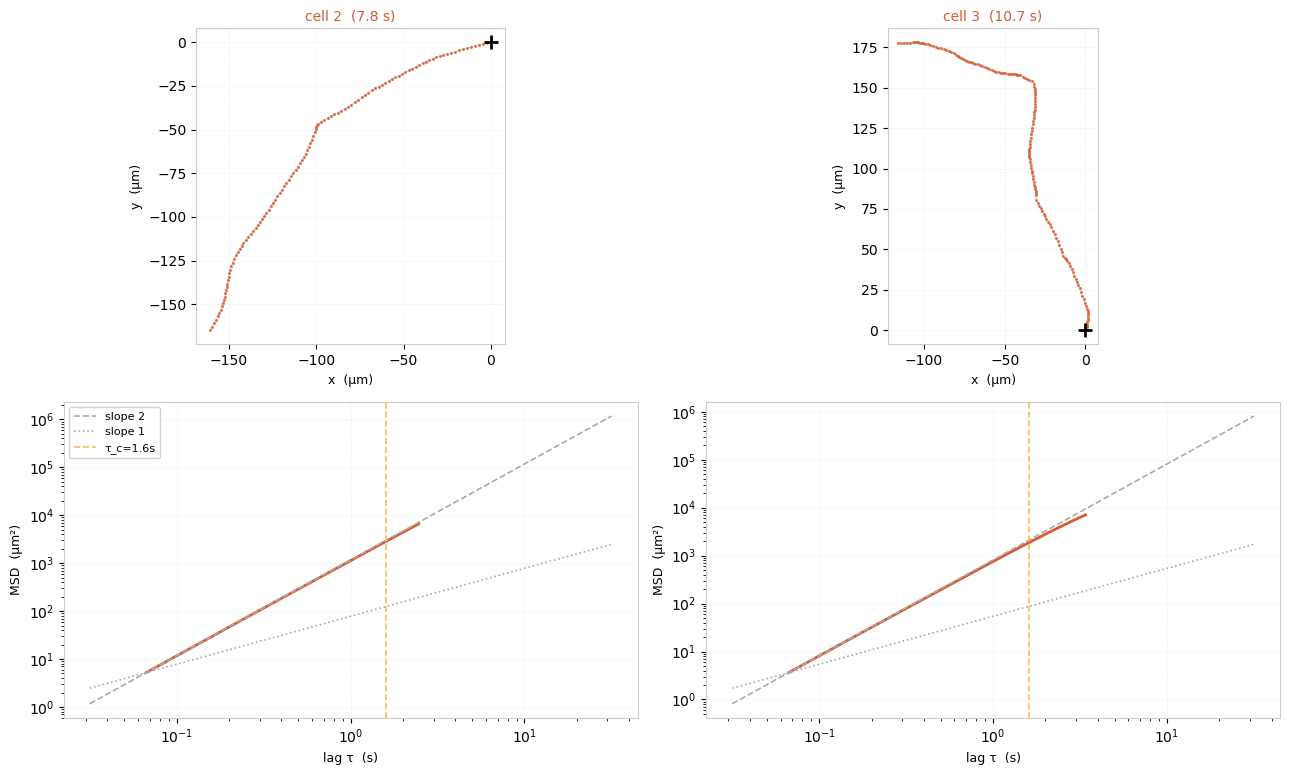

In [37]:
# ============================================================
# Sub-topic 2 — Q1c: Trajectory + MSD for ballistic vs diffusive
# Two separate figures:
#   Figure 1 — 3 ballistic cells: row1=trajectory, row2=MSD
#   Figure 2 — 3 diffusive cells: row1=trajectory, row2=MSD
# ============================================================


def plot_traj_msd_linear(V_10min, indices, 
                         angle_threshold, color, title, filename, msd_scale='log'):
    fig, axes = plt.subplots(2, len(indices), figsize=(13, 8), facecolor='white')
    fig.subplots_adjust(hspace=0.45, wspace=0.35)

    for col, idx in enumerate(indices):
        df, fps   = metrics.extract_clean(V_10min, idx)
        lags, msd = metrics.compute_msd(df)
        is_tumble = df['angle_change_deg'] > angle_threshold

        x = df['x_um'].values - df['x_um'].iloc[0]
        y = df['y_um'].values - df['y_um'].iloc[0]

        # ── row 0: trajectory ─────────────────────────────────
        ax = axes[0, col]
        ax.set_facecolor('white')
        ax.set_aspect('equal')
        ax.grid(True, ls='--', lw=0.4, alpha=0.35, color='#ccc')
        for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

        ax.plot(x, y, color='#ddd', lw=1.0, zorder=1)
        ax.plot(x[~is_tumble], y[~is_tumble], '.', color=color, ms=2.5, alpha=0.7, zorder=2)
        # ax.plot(x[is_tumble], y[is_tumble], 'o', color='#555', ms=4, alpha=0.6, zorder=3)
        ax.plot(0, 0, '+k', ms=10, mew=2, zorder=5)
        ax.set_title(f'cell {idx}  ({df["time_s"].max():.1f} s)', fontsize=10, pad=5, color=color)
        ax.set_xlabel('x  (µm)', fontsize=9)
        ax.set_ylabel('y  (µm)', fontsize=9)

        # ── row 1: MSD ────────────────────────────────────────
        ax = axes[1, col]
        ax.set_facecolor('white')
        ax.grid(True, ls='--', lw=0.4, alpha=0.35, color='#ccc')
        for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

        anchor, t0 = msd[0], lags[0]

        if msd_scale == 'log':
            ax.loglog(lags, msd, color=color, lw=2)
            ax.loglog(ref_t, anchor*(ref_t/t0)**2, '--', color='#aaa', lw=1.2, label='slope 2')
            ax.loglog(ref_t, anchor*(ref_t/t0)**1, ':',color='#aaa', lw=1.2, label='slope 1')
        else:
            ax.plot(lags, msd, color=color, lw=2)
            ax.plot(ref_t, anchor*(ref_t/t0)**2, '--', color='#aaa', lw=1.2, label='∝ τ²  (ballistic)')
            ax.plot(ref_t, anchor*(ref_t/t0)**1, ':', color='#aaa', lw=1.2, label='∝ τ  (diffusive)')
            ax.set_xlim(0, lags[-1] * 1.05)
            ax.set_ylim(0, msd.max() * 1.15)
        ax.axvline(tau_c, color='#F0C060', lw=1.2, ls='--', label=f'τ_c={tau_c}s')
        ax.set_xlabel('lag τ  (s)', fontsize=9)
        ax.set_ylabel('MSD  (µm²)', fontsize=9)
        if col == 0:
            ax.legend(fontsize=8, framealpha=0.9, edgecolor='#ccc')


    fig.suptitle(title, fontsize=12, y=1.01, color=color)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

plot_traj_msd_linear(
    V_10min = V_10min,
    indices  = [2, 3],
    angle_threshold = angle_threshold,
    color    = '#D85A30',
    title    = "", #'BALLISTIC cells — short trajectory, only slope-2 visible',
    filename = 'Q1c_ballistic.png',
)

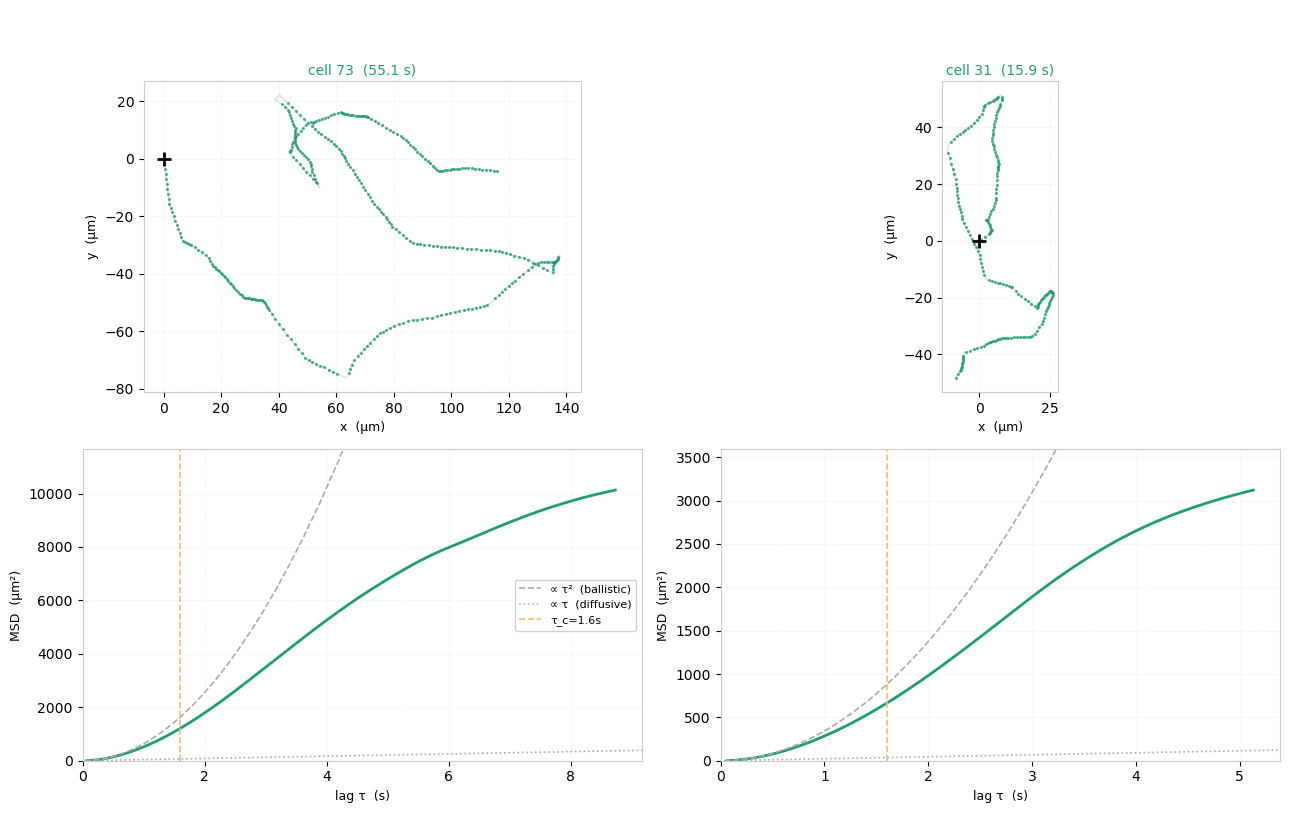

In [38]:
plot_traj_msd_linear(
    V_10min = V_10min,
    indices   = [73, 31],
    angle_threshold = angle_threshold,
    color     = '#1D9E75',
    title     = " ", ##'DIFFUSIVE cells — long trajectory, crossover at τ_c visible',
    filename  = 'Q1c_diffusive.png',
    msd_scale = 'linear',
)

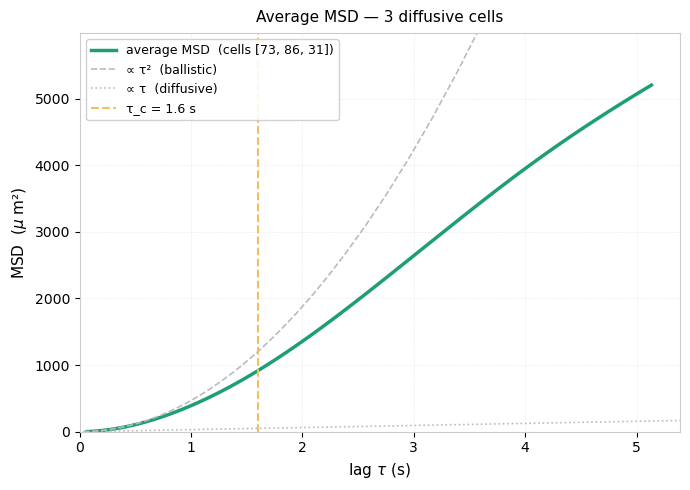

In [39]:
# ============================================================
# Sub-topic 2 — Average MSD of 3 diffusive cells
# ============================================================

CELLS = [73, 86, 31]

# ── compute average MSD ──────────────────────────────────────
all_lags, all_msd = [], []
for idx in CELLS:
    df, fps   = metrics.extract_clean(V_10min, idx)
    lags, msd = metrics.compute_msd(df)
    all_lags.append(lags)
    all_msd.append(msd)

min_len  = min(len(m) for m in all_msd)
avg_lags = all_lags[0][:min_len]
avg_msd  = np.mean([m[:min_len] for m in all_msd], axis=0)
# ── plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')
ax.grid(True, ls='--', lw=0.4, alpha=0.4, color='#ccc')
for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

anchor, t0 = avg_msd[0], avg_lags[0]

ax.plot(avg_lags, avg_msd, color='#1D9E75', lw=2.5, label=f'average MSD  (cells {CELLS})')
ax.plot(ref_t, anchor*(ref_t/t0)**2, '--', color='#bbb', lw=1.2, label='∝ τ²  (ballistic)')
ax.plot(ref_t, anchor*(ref_t/t0)**1, ':',  color='#bbb',lw=1.2, label='∝ τ  (diffusive)')
ax.axvline(tau_c, color='#F0C060', lw=1.5, ls='--', label=f'τ_c = {tau_c} s')

ax.set_xlim(0, avg_lags[-1] * 1.05)
ax.set_ylim(0, avg_msd.max() * 1.15)
ax.set_xlabel(r'lag $\tau$ (s)', fontsize=11)
ax.set_ylabel(r'MSD  ($\mu$ m²)', fontsize=11)
ax.set_title('Average MSD — 3 diffusive cells', fontsize=11, pad=8)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# Sub-topic 2 — Q1b: Verify MSD ∝ v²τ² in ballistic regime
#
# If MSD = v²τ²  then  MSD/τ² = v²  (a constant)
#
# We check this two ways:
#   1. Plot MSD/τ² vs τ — should be flat in ballistic regime
#   2. Compare the plateau value to v² from speed data directly
# ============================================================

BALLISTIC_IDX = [1, 2, 3]   # cells confirmed ballistic in Q1
COLORS        = ['#D85A30', '#E8825A', '#F0C060']

for idx, color in zip(BALLISTIC_IDX, COLORS):
    
    df, fps      = metrics.extract_clean(V_10min, idx)
    lags, msd    = metrics.compute_msd(df)

    # ── 1. MSD / τ² ──────────────────────────────────────────
    msd_norm = msd / lags**2  

    # ── 2. v² from speed data directly ───────────────────────
    is_run = df['angle_change_deg'] < angle_threshold
    v_mean = df.loc[is_run, 'speed_um_s'].mean()
    v2     = v_mean**2
    t2 = lags**2
    print(f'msd:{msd.mean()} -- v2t2:{t2.mean() * v2}--v2:{v2}')

    # print comparison
    plateau = np.median(msd_norm[lags < tau_c * 0.5])
    print(f"Cell {idx}:")
    print(f"MSD/τ² plateau (ballistic region) = {plateau:.1f} µm²/s²")
    print(f" v² from speed data = {v2:.1f} µm²/s²")
    print(f"ratio (should be ≈ 1) = {plateau/v2:.2f}")
    print()

msd:2028.9589873517757 -- v2t2:2478.4395116677797--v2:284.0075834607846
Cell 1:
MSD/τ² plateau (ballistic region) = 280.9 µm²/s²
 v² from speed data = 284.0 µm²/s²
ratio (should be ≈ 1) = 0.99

msd:2330.687579380677 -- v2t2:2438.170656875353--v2:1154.922942730431
Cell 2:
MSD/τ² plateau (ballistic region) = 1149.1 µm²/s²
 v² from speed data = 1154.9 µm²/s²
ratio (should be ≈ 1) = 0.99

msd:2635.2683871508925 -- v2t2:3194.489995546717--v2:805.1832513047179
Cell 3:
MSD/τ² plateau (ballistic region) = 782.4 µm²/s²
 v² from speed data = 805.2 µm²/s²
ratio (should be ≈ 1) = 0.97



## Q2

From your MSD plot in Q1, estimate the crossover time $\hat{\tau}_c$ visually — this is approximately where the log-log slope transitions from 2 toward 1. Now compute the predicted \tau_c from the formula:

$$\tau_c = \frac{\tau_\text{run}}{1-\cos\theta}$$

Use your measured $\hat{\tau}_\text{run}$ from Sub-topic 1 Q3, and the mean tumble angle from the data: compute $\bar{\theta}$ as the mean of col 10 over all tumble frames (col 10 > 45°) across all trajectories.

How well does the formula prediction agree with your visual estimate from the MSD? Express the difference as a percentage.

τ_run            = 1.43 s
θ_mean           = 79.6°
τ_c (formula)    = 1.75 s
τ_c(s) = 0.27 s, slope = 1.97
τ_c(s) = 0.47 s, slope = 1.95
τ_c(s) = 0.67 s, slope = 1.92
τ_c(s) = 0.87 s, slope = 1.87
τ_c(s) = 1.07 s, slope = 1.80
τ_c(s) = 1.27 s, slope = 1.72
τ_c(s) = 1.47 s, slope = 1.62
τ_c(s) = 1.67 s, slope = 1.50
↑ crossover here
τ_c (visual)     = 1.73 s
Difference       = 0.7%


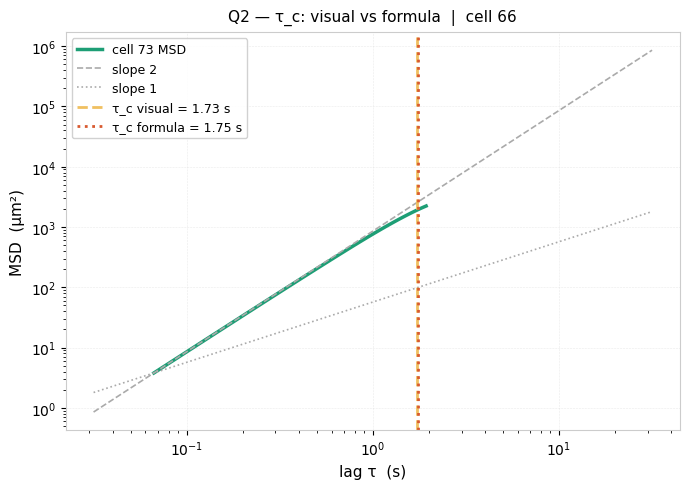

In [41]:
# ============================================================
# Sub-topic 2 — Q2: Read off τ_c and compare to formula
#
# Formula:  τ_c = τ_run / (1 - cos θ)
#
# # Where:
#   τ_run = mean run duration       (from Sub-topic 1 Q3)
#   θ     = mean tumble angle       (from angle_change_deg column)
#   τ_c   = correlation time        (crossover on MSD log-log plot)
# ============================================================

# ── 1. formula prediction (from Q3 results) ──────────────────
tumble_angles = []
tau_hat = np.mean(run_durations)

for i in range(len(V_10min['Speeds'][0, 0])):
    df, fps = metrics.extract_clean(V_10min, i)
    if len(df) < 10: continue
    tumble_angles.extend(
        df.loc[df['angle_change_deg'] > angle_threshold,'angle_change_deg'].tolist())
theta_mean    = np.mean(tumble_angles)
tau_c_formula = tau_hat / (1 - np.cos(np.radians(theta_mean)))

print(f"τ_run            = {tau_hat:.2f} s")
print(f"θ_mean           = {theta_mean:.1f}°")
print(f"τ_c (formula)    = {tau_c_formula:.2f} s")

# ── 2. visual estimate from cell 73 MSD ──────────────────────
cell_idx = 66
df, fps = metrics.extract_clean(V_10min, cell_idx)
lags, msd = metrics.compute_msd(df)

# find where slope first drops below 1.5
tau_c_visual = np.nan
for k in range(3, len(lags) - 3):
    s = np.polyfit(np.log10(lags[k-2:k+3]), np.log10(msd[k-2:k+3]), 1)[0]
    if k % 3 == 0:   # print every 3rd point to keep output short
        print(f"τ_c(s) = {lags[k]:.2f} s, slope = {s:.2f}")
    if s < 1.5:
        tau_c_visual = lags[k]
        print(f"↑ crossover here")
        break

print(f"τ_c (visual)     = {tau_c_visual:.2f} s")
print(f"Difference       = {100*abs(tau_c_formula-tau_c_visual)/tau_c_visual:.1f}%")

# ── 3. plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')
ax.grid(True, ls='--', lw=0.4, alpha=0.4, color='#ccc')
for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

anchor, t0 = msd[0], lags[0]


ax.loglog(lags, msd, color='#1D9E75', lw=2.5, label='cell 73 MSD')
ax.loglog(ref_t, anchor*(ref_t/t0)**2, '--', color='#aaa', lw=1.2, label='slope 2')
ax.loglog(ref_t, anchor*(ref_t/t0)**1, ':',  color='#aaa', lw=1.2, label='slope 1')
ax.axvline(tau_c_visual,  color='#F0C060', lw=2, ls='--', label=f'τ_c visual = {tau_c_visual:.2f} s')
ax.axvline(tau_c_formula, color='#D85A30', lw=2, ls=':',
           label=f'τ_c formula = {tau_c_formula:.2f} s')

ax.set_xlabel('lag τ  (s)', fontsize=11)
ax.set_ylabel('MSD  (µm²)', fontsize=11)
ax.set_title(f'Q2 — τ_c: visual vs formula  |  cell {cell_idx}', fontsize=11, pad=8)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()

plt.show()

# chemotaxis

In [42]:
# ============================================================
# Sub-topic 3 — Q1: Does the population drift?
#
# Compare net displacement Δx, Δy, Δz between:
#   - V_Reference_0503_bulk  (no gradient)
#   - V_MeAsp_0511_bulk      (MeAsp gradient)
#
# The axis with a shifted mean = gradient direction
# ============================================================

datasets = {
    'no gradient' : ecoli_mat['V_Reference_0503_bulk'],
    'gradient'    : ecoli_mat['V_MeAsp_0511_bulk'],
}

for row, (name, V_cond) in enumerate(datasets.items()):
    dx, dy, dz = [], [], []

    for i in range(len(V_cond['Speeds'][0, 0])):
        df, fps = metrics.extract_clean(V_cond, i)
        if len(df) < 10: continue
        dx.append(df['x_um'].iloc[-1] - df['x_um'].iloc[0])
        dy.append(df['y_um'].iloc[-1] - df['y_um'].iloc[0])
        dz.append(df['z_um'].iloc[-1] - df['z_um'].iloc[0])

    dx, dy, dz = np.array(dx), np.array(dy), np.array(dz)

    print(f"\n{name}:")
    print(f"  Δx mean = {dx.mean():.2f} µm")
    print(f"  Δy mean = {dy.mean():.2f} µm")
    print(f"  Δz mean = {dz.mean():.2f} µm")


no gradient:
  Δx mean = -0.98 µm
  Δy mean = -0.32 µm
  Δz mean = 0.24 µm

gradient:
  Δx mean = -7.87 µm
  Δy mean = -0.07 µm
  Δz mean = -0.21 µm


## Q3

Best example cell: 7696  (13 runs in each direction)


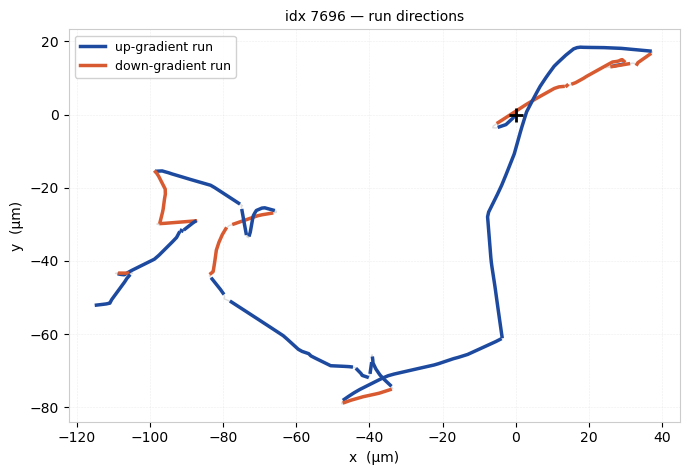

In [43]:
# ============================================================
# Sub-topic 3 — Q3: Run duration asymmetry
#
# Up-gradient run   = cell moving in -x direction (toward attractant)
# Down-gradient run = cell moving in +x direction (away from attractant)
#
# If chemotaxis is working: up-gradient runs should be LONGER
# ============================================================

# ── STEP 3: find best example cell ────────────────────────────
V_grad = ecoli_mat['V_MeAsp_0511_bulk']

best_idx, best_n = 0, 0
for i in range(len(V_grad['Speeds'][0, 0])):
    df, fps = metrics.extract_clean(V_grad, i)
    if len(df) < 30: continue
    up, down = metrics.get_run_durations_by_direction(df, fps, angle_threshold)
    n = min(len(up), len(down))
    if n > best_n:
        best_n, best_idx = n, i

print(f"Best example cell: {best_idx}  ({best_n} runs in each direction)")

df_ex, fps_ex = metrics.extract_clean(V_grad, best_idx)
fig, ax = plt.subplots(1, 1, figsize=(7, 7), facecolor='white')
ax.set_facecolor('white')
ax.set_aspect('equal')
ax.grid(True, ls='--', lw=0.4, alpha=0.35, color='#ccc')
for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

df_ex2 = df_ex.copy()
df_ex2['is_run'] = df_ex2['angle_change_deg'] < angle_threshold # run
df_ex2['seg'] = (df_ex2['is_run'] != df_ex2['is_run'].shift(1)).cumsum() #     did the state change?

x = df_ex2['x_um'].values - df_ex2['x_um'].iloc[0]
y = df_ex2['y_um'].values - df_ex2['y_um'].iloc[0]
ax.plot(x, y, color='#ddd', lw=1.0, zorder=1)

for _, grp in df_ex2[df_ex2['is_run']].groupby('seg'):
    idx_g = grp.index
    gx = x[idx_g]
    gy = y[idx_g]
    c  = '#1D4A9E' if grp['vx_um_s'].mean() < 0 else '#D85A30'  
    ax.plot(gx, gy, color=c, lw=2.5, zorder=2)

ax.plot(0, 0, '+k', ms=10, mew=2, zorder=5)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='#1D4A9E', lw=2.5, label='up-gradient run'),
    Line2D([0],[0], color='#D85A30', lw=2.5, label='down-gradient run'),
], fontsize=9, framealpha=0.9, edgecolor='#ccc')
ax.set_xlabel('x  (µm)', fontsize=10)
ax.set_ylabel('y  (µm)', fontsize=10)
ax.set_title(f'idx {best_idx} — run directions', fontsize=10, pad=6)
plt.tight_layout()
plt.savefig('Q3_run_directions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [44]:
df_ex2

,frame,time_s,x_um,y_um,z_um,vx_um_s,vy_um_s,vz_um_s,speed_um_s,angle_change_deg,is_run,seg
0,1406,93.733333,134.307879,259.244369,27.429790,-12.707170,-16.304802,-10.251425,23.074021,11.314749,True,1
1,1407,93.800000,133.409547,258.157613,26.746363,-13.475217,-14.422282,-10.742235,22.471744,16.901386,True,1
2,1408,93.866667,132.511183,257.321399,25.997492,-13.475789,-12.540666,-12.656302,22.339364,24.705358,True,1
3,1409,93.933333,131.612775,256.485524,25.058856,-13.475757,-8.555657,-14.079103,21.284183,24.341110,True,1
4,1410,94.000000,130.714416,256.180644,24.120279,-13.475173,-4.570553,-14.078950,20.017170,19.694308,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
464,1870,124.666667,22.854093,207.581399,22.513297,-7.494445,-1.622660,6.000261,9.736676,40.270433,True,57
465,1871,124.733333,22.354559,207.472762,22.913336,-9.978902,-1.609846,6.002390,11.755797,24.945793,True,57
466,1872,124.800000,21.523573,207.366753,23.313615,-13.114333,-1.609845,6.002474,14.512305,9.817575,True,57
467,1873,124.866667,20.605981,207.258116,23.713666,-13.765845,-1.624240,6.001349,15.104729,0.489058,True,57


In [45]:
df_ex2.seg.tail(5)

464    57
465    57
466    57
467    57
468    57
Name: seg, dtype: int64

* the white gaps are because the full trajectory is plotted, but the tumble segments are not colored

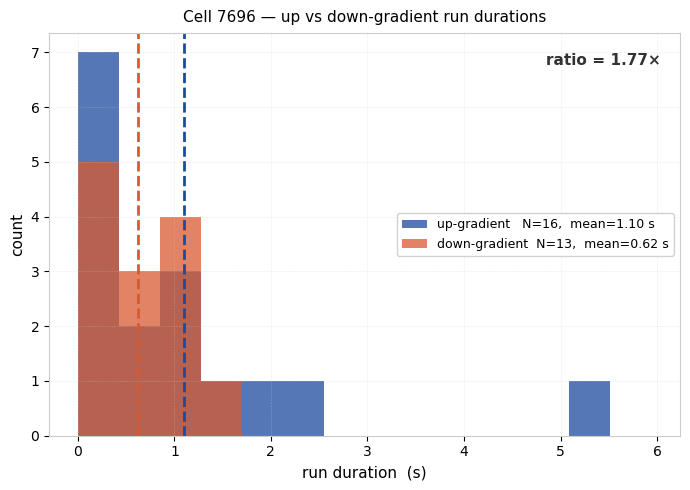

Up-gradient   mean = 1.10 s  (N=16)
Down-gradient mean = 0.62 s  (N=13)
Ratio              = 1.77×


In [46]:
up_ex, down_ex = metrics.get_run_durations_by_direction(df_ex, fps_ex, angle_threshold)

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')
ax.grid(True, ls='--', lw=0.4, alpha=0.4, color='#ccc')
for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

bins = np.linspace(0, max(max(up_ex, default=1), max(down_ex, default=1)) * 1.1, 15)

ax.hist(up_ex,   bins=bins, color='#1D4A9E', alpha=0.75, label=f'up-gradient   N={len(up_ex)},  mean={np.mean(up_ex):.2f} s')
ax.hist(down_ex, bins=bins, color='#D85A30', alpha=0.75, label=f'down-gradient  N={len(down_ex)},  mean={np.mean(down_ex):.2f} s')

ax.axvline(np.mean(up_ex),   color='#1D4A9E', lw=2, ls='--')
ax.axvline(np.mean(down_ex), color='#D85A30', lw=2, ls='--')

ratio = np.mean(up_ex) / np.mean(down_ex)
ax.text(0.97, 0.95, f'ratio = {ratio:.2f}×', transform=ax.transAxes, ha='right', va='top', fontsize=11, fontweight='bold', color='#333')

ax.set_xlabel('run duration  (s)', fontsize=11)
ax.set_ylabel('count', fontsize=11)
ax.set_title(f'Cell {best_idx} — up vs down-gradient run durations',
             fontsize=11, pad=8)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
plt.savefig('Q3_example_cell_durations.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"Up-gradient   mean = {np.mean(up_ex):.2f} s  (N={len(up_ex)})")
print(f"Down-gradient mean = {np.mean(down_ex):.2f} s  (N={len(down_ex)})")
print(f"Ratio              = {ratio:.2f}×")


Population results:
  Up-gradient mean   = 1.546 s  (N=7774)
  Down-gradient mean = 1.227 s  (N=7910)
  Ratio              = 1.259×


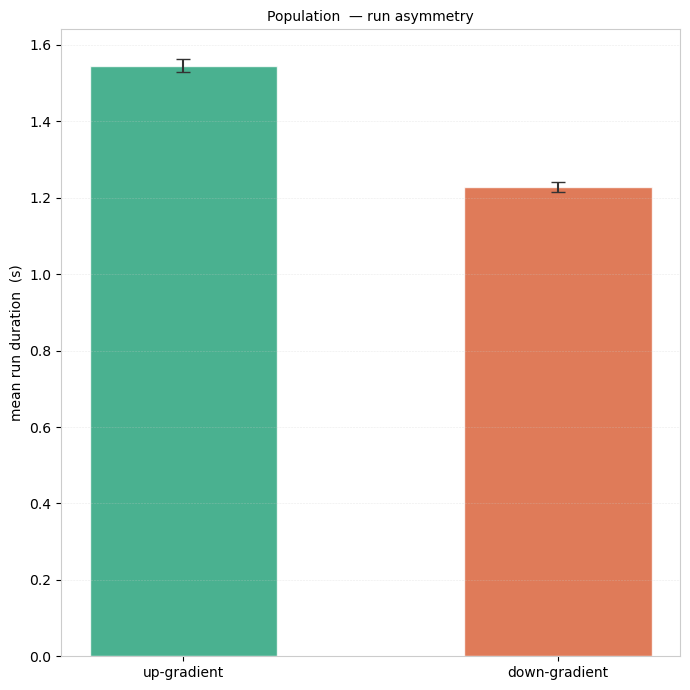

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), facecolor='white')
ax.set_facecolor('white')
ax.grid(True, axis='y', ls='--', lw=0.4, alpha=0.4, color='#ccc')
for sp in ax.spines.values(): sp.set_edgecolor('#ccc')

all_up, all_down = [], []
for i in range(len(V_grad['Speeds'][0,0])):
    df, fps = metrics.extract_clean(V_grad, i)
    if len(df) < 20: continue
    up, down = metrics.get_run_durations_by_direction(df, fps, angle_threshold)
    all_up.extend(up); all_down.extend(down)

means = [np.mean(all_up), np.mean(all_down)]
sems  = [np.std(all_up)/np.sqrt(len(all_up)),
         np.std(all_down)/np.sqrt(len(all_down))]

bars = ax.bar(['up-gradient', 'down-gradient'], means,
              color=['#1D9E75', '#D85A30'], alpha=0.8,
              edgecolor='white', width=0.5)
ax.errorbar(['up-gradient', 'down-gradient'], means, yerr=sems,
            fmt='none', color='#333', capsize=5, lw=1.5)

ratio = means[0] / means[1]
 
ax.set_ylabel('mean run duration  (s)', fontsize=10)
ax.set_title('Population  — run asymmetry', fontsize=10, pad=6)

print(f"\nPopulation results:")
print(f"  Up-gradient mean   = {means[0]:.3f} s  (N={len(all_up)})")
print(f"  Down-gradient mean = {means[1]:.3f} s  (N={len(all_down)})")
print(f"  Ratio              = {ratio:.3f}×")

# fig.suptitle('Q3 — Run duration asymmetry  |  V_MeAsp_0511_bulk',fontsize=11, y=1.01, color='#222')
plt.tight_layout()
plt.show()